# Rare-Disease Synthetic Data Augmentation — Day 1: Data + Baseline

**Research question:** Can generative augmentation improve recognition of a *rare* skin-lesion class when real examples are scarce?

Day 1 builds the **control group** that every later experiment is compared against:

1. Download HAM10000 (ISIC 2018 Task 3 = the HAM10000 part of ISIC 2019)
2. Inspect the class distribution and pick the rare class
3. Stratified, **lesion-grouped** train / val / test split (70 / 15 / 15)
4. Resize + normalise into a PyTorch `Dataset` / `DataLoader`
5. Train ResNet-18 (ImageNet transfer learning) on the data as-is — **no augmentation**
6. Evaluate honestly: rare-class precision / recall / F1, not just accuracy
7. Log the "before" numbers to `results/results_log.csv`

**Before running:** `Runtime → Change runtime type → T4 GPU`, then `Runtime → Run all`.
Total time ≈ 20–30 min (download ~5 min, resize ~3 min, training ~10–15 min).

**Setup (one time):** upload `rare-disease-aug.zip` to the top level of *My Drive*. The first cell unzips it.

## 0 · Setup

In [4]:
!nvidia-smi --query-gpu=name,memory.total --format=csv || echo "⚠️ No GPU — Runtime > Change runtime type > T4 GPU"

name, memory.total [MiB]
Tesla T4, 15360 MiB


In [5]:
import os, sys, zipfile
from pathlib import Path

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Project code + results live on Drive (persist between sessions).
# Raw images live on the Colab VM's local disk (fast; deleted when the runtime ends — that's fine,
# only the small resized cache is needed after today).
PROJECT_DIR = Path(os.environ.get('RDA_PROJECT_DIR', '/content/drive/MyDrive/rare-disease-aug'))
RAW_DIR     = Path(os.environ.get('RDA_RAW_DIR', '/content/ham10000_raw'))

if not (PROJECT_DIR / 'src').exists():
    zip_path = PROJECT_DIR.parent / 'rare-disease-aug.zip'
    assert zip_path.exists(), f'Upload rare-disease-aug.zip to {PROJECT_DIR.parent} first'
    zipfile.ZipFile(zip_path).extractall(PROJECT_DIR.parent)
    print('Unzipped project to', PROJECT_DIR)

os.chdir(PROJECT_DIR)
sys.path.insert(0, str(PROJECT_DIR))
print('Project dir:', PROJECT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project dir: /content/drive/MyDrive/rare-disease-aug


In [6]:


import numpy as np, pandas as pd, torch, torchvision, matplotlib.pyplot as plt
from IPython.display import display

from src.config import Paths, TrainConfig, CLASS_CODES, CLASS_NAMES
from src.data.download import download_ham10000
from src.data.explore import (build_metadata, class_distribution, pick_rare_class,
                              plot_class_distribution, plot_examples, save_dataset_info)
from src.data.split import make_split, split_summary
from src.data.preprocess import build_image_cache
from src.data.dataset import attach_cache_index, make_loaders, denormalize
from src.train import run_experiment

pd.set_option('display.width', 160)
paths = Paths(PROJECT_DIR, RAW_DIR)
paths.make_dirs()
print(f'torch {torch.__version__} | torchvision {torchvision.__version__} | CUDA: {torch.cuda.is_available()}')

torch 2.11.0+cu128 | torchvision 0.26.0+cu128 | CUDA: True


## 1 · Download HAM10000

Public ISIC bucket, no login. Three files: the images (~2.6 GB), the one-hot diagnosis labels,
and the **lesion groupings** (`lesion_id`). The last one matters: HAM10000 has ~10k images of only ~7.5k lesions,
so the split must keep all photos of one lesion together. Re-running this cell skips anything already present.

In [7]:
download_ham10000(paths)

ISIC2018_Task3_Training_Input.zip:   0%|          | 0.00/2.77G [00:00<?, ?B/s]

unzip ISIC2018_Task3_Training_Input.zip:   0%|          | 0/10018 [00:00<?, ?file/s]

ISIC2018_Task3_Training_GroundTruth.zip:   0%|          | 0.00/36.7k [00:00<?, ?B/s]

unzip ISIC2018_Task3_Training_GroundTruth.zip:   0%|          | 0/4 [00:00<?, ?file/s]

ISIC2018_Task3_Training_LesionGroupings.csv:   0%|          | 0.00/493k [00:00<?, ?B/s]

Done. 10015 images in /content/ham10000_raw/ISIC2018_Task3_Training_Input


## 2 · Inspect the class distribution and pick the rare class

Rule (from the blueprint): a class with **well under 2 %** of the images. Among those candidates we take the one with
the **fewest distinct lesions** — that is the real number of independent examples a classifier (and, on Day 3, the GAN)
can learn from. Set `RARE_OVERRIDE = 'VASC'` to force the other candidate.

In [8]:
meta = build_metadata(paths)
dist = class_distribution(meta)

RARE_OVERRIDE = None          # e.g. 'VASC'
RARE = pick_rare_class(dist, RARE_OVERRIDE)
save_dataset_info(paths, dist, RARE)

print(f'{len(meta):,} images | {meta.lesion_id.nunique():,} distinct lesions\n')
display(dist.style.format({'pct_images': '{:.2f}%', 'imgs_per_lesion': '{:.2f}'}))
r = dist.loc[RARE]
print(f"\nRare class → {RARE} ({CLASS_NAMES[RARE]}): {r.images} images = {r.pct_images:.2f}% of the data, "
      f"from only {r.lesions} distinct lesions.")
print(f"Majority class NV has {dist.loc['NV','images'] / r.images:.0f}× more images.")

10,015 images | 7,470 distinct lesions



,name,images,lesions,pct_images,imgs_per_lesion,under_2pct
class,,,,,,
NV,Melanocytic nevus,6705,5403,66.95%,1.24,False
MEL,Melanoma,1113,614,11.11%,1.81,False
BKL,Benign keratosis,1099,727,10.97%,1.51,False
BCC,Basal cell carcinoma,514,327,5.13%,1.57,False
AKIEC,Actinic keratosis / Bowen's,327,228,3.27%,1.43,False
VASC,Vascular lesion,142,98,1.42%,1.45,True
DF,Dermatofibroma,115,73,1.15%,1.58,True



Rare class → DF (Dermatofibroma): 115 images = 1.15% of the data, from only 73 distinct lesions.
Majority class NV has 58× more images.


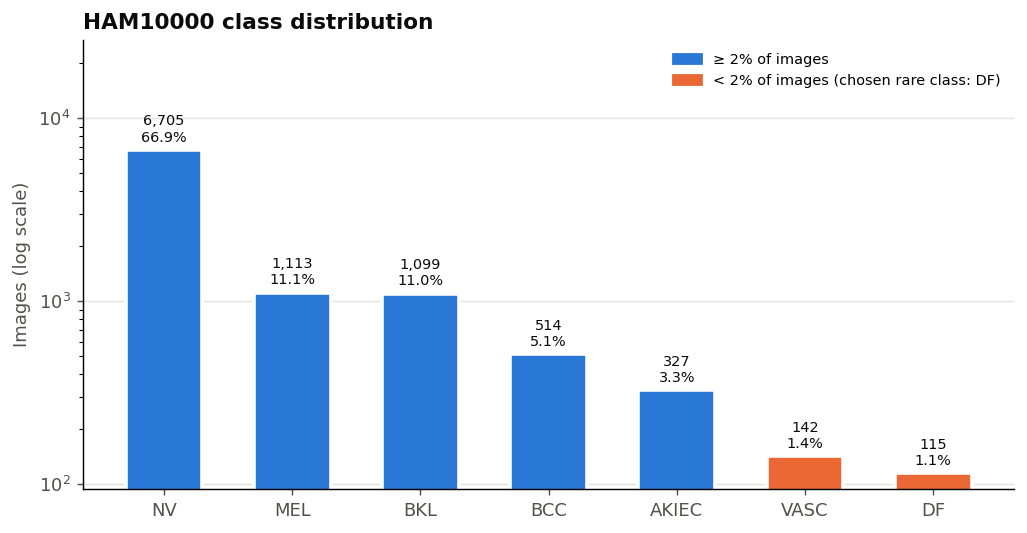

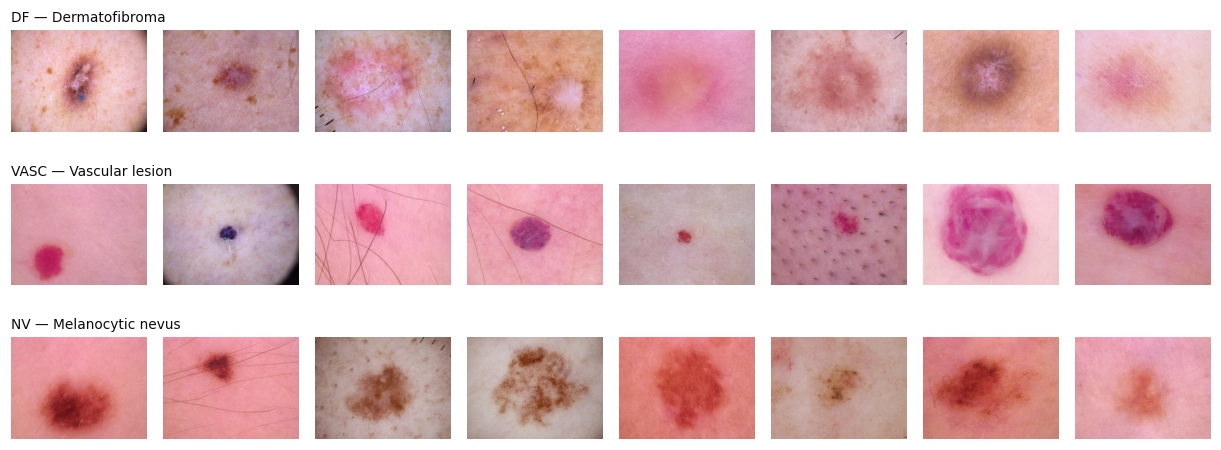

In [9]:
plot_class_distribution(dist, RARE, paths.figures_dir / 'class_distribution.png')
candidates = [RARE] + [c for c in dist[dist.under_2pct].index if c != RARE]
plot_examples(meta, candidates + ['NV'], paths.figures_dir / 'rare_class_examples.png')

## 3 · Stratified, lesion-grouped train / val / test split (70 / 15 / 15)

*Stratified* keeps each class's share (including the rare class) roughly equal across splits.
*Grouped by lesion* guarantees no lesion appears in two splits — otherwise the test score is inflated.
The split is saved to Drive and **reused unchanged by every later experiment** (same test images for all four configurations).

In [10]:
split = make_split(meta, paths, seed=42)
display(split_summary(split, RARE))

leaks = (split.groupby('lesion_id')['split'].nunique() > 1).sum()
print(f'Lesions appearing in more than one split: {leaks}  (must be 0)')
print(f"Rare-class images per split: " + ", ".join(
    f"{s}={((split.split == s) & (split.label == RARE)).sum()}" for s in ['train', 'val', 'test']))

Saved split to /content/drive/MyDrive/rare-disease-aug/data/splits/split_seed42.csv


split,train,val,test,train_lesions,val_lesions,test_lesions
MEL,773 (11.1%),173 (11.3%),167 (11.1%),430,92,92
NV,4683 (67.1%),1018 (66.4%),1004 (66.8%),3782,810,811
BCC,361 (5.2%),82 (5.4%),71 (4.7%),229,49,49
AKIEC,222 (3.2%),53 (3.5%),52 (3.5%),159,34,35
BKL,772 (11.1%),160 (10.4%),167 (11.1%),509,109,109
DF ← rare,71 (1.0%),24 (1.6%),20 (1.3%),51,11,11
VASC,99 (1.4%),22 (1.4%),21 (1.4%),69,15,14
TOTAL,6981 (100.0%),1532 (100.0%),1502 (100.0%),5229,1120,1121


Lesions appearing in more than one split: 0  (must be 0)
Rare-class images per split: train=71, val=24, test=20


## 4 · Preprocess → PyTorch Dataset / DataLoader

Every image is resized once to 224×224 and cached as a single `uint8` array on Drive (~1.5 GB), then loaded into RAM.
The `Dataset` applies only `ToTensor` + ImageNet normalisation — **no augmentation** today.

In [11]:
images = build_image_cache(meta, paths, size=224)
split = attach_cache_index(split, meta)
print('cache:', images.shape, images.dtype)

loaders = make_loaders(images, split, batch_size=64, num_workers=2)
for s, dl in loaders.items():
    print(f'{s:>5}: {len(dl.dataset):5d} images, {len(dl):3d} batches')

x, y = next(iter(loaders['train']))
print(f'\nbatch x {tuple(x.shape)} {x.dtype}, mean {x.mean():.2f}, std {x.std():.2f} (≈0 / ≈1 after normalisation)')
print('batch y', tuple(y.shape), y[:12].tolist())

resize→224px:   0%|          | 0/10015 [00:00<?, ?it/s]

Saved /content/drive/MyDrive/rare-disease-aug/data/processed/images_224px_uint8.npy (1.51 GB)
Loading images_224px_uint8.npy into RAM ...
cache: (10015, 224, 224, 3) uint8
train:  6981 images, 110 batches
  val:  1532 images,  24 batches
 test:  1502 images,  24 batches

batch x (64, 3, 224, 224) torch.float32, mean 0.84, std 0.76 (≈0 / ≈1 after normalisation)
batch y (64,) [1, 0, 1, 3, 1, 1, 1, 1, 1, 3, 1, 1]


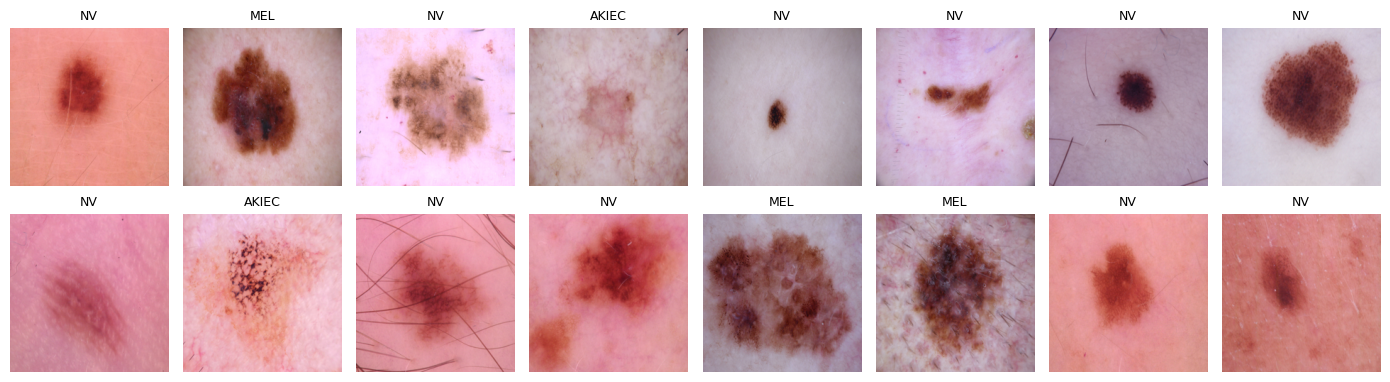

In [12]:
# Sanity check: what the network actually sees (after un-normalising for display)
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for ax, img, lab in zip(axes.flat, x[:16], y[:16]):
    ax.imshow(denormalize(img).permute(1, 2, 0).numpy()); ax.set_title(CLASS_CODES[lab], fontsize=9); ax.axis('off')
plt.tight_layout(); plt.show()

## 5 · Train the baseline ResNet-18 (control group)

* ImageNet-pretrained ResNet-18, all layers fine-tuned, new 7-way head
* AdamW, lr 1e-4, weight decay 1e-4, cosine schedule, 15 epochs, batch 64, mixed precision
* Plain cross-entropy — **no augmentation, no class weights, no resampling**
* Checkpoint chosen on **validation macro-F1** (the same rule will be used for every configuration, so we never tune on the rare class or the test set)

Each epoch prints the rare-class precision / recall / F1 on validation and how many images were predicted as the rare class.

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 173MB/s]


Device: cuda | AMP: True | train=6981 (rare DF: 71) | val=1532 | test=1502
ep 01/15 | loss 0.7041 / val 0.5985 | val acc 0.785 macroF1 0.496 | DF P 0.00 R 0.00 F1 0.00 (pred 1) | 44s  *best*
ep 02/15 | loss 0.2431 / val 0.5919 | val acc 0.815 macroF1 0.601 | DF P 0.55 R 0.25 F1 0.34 (pred 11) | 14s  *best*
ep 03/15 | loss 0.0927 / val 0.5977 | val acc 0.817 macroF1 0.624 | DF P 0.56 R 0.21 F1 0.30 (pred 9) | 14s  *best*
ep 04/15 | loss 0.0548 / val 0.6181 | val acc 0.824 macroF1 0.641 | DF P 0.50 R 0.29 F1 0.37 (pred 14) | 14s  *best*
ep 05/15 | loss 0.0306 / val 0.6927 | val acc 0.805 macroF1 0.630 | DF P 0.42 R 0.33 F1 0.37 (pred 19) | 14s
ep 06/15 | loss 0.0279 / val 0.6442 | val acc 0.828 macroF1 0.661 | DF P 0.53 R 0.38 F1 0.44 (pred 17) | 14s  *best*
ep 07/15 | loss 0.0108 / val 0.6834 | val acc 0.827 macroF1 0.645 | DF P 0.53 R 0.33 F1 0.41 (pred 15) | 15s
ep 08/15 | loss 0.0140 / val 0.6431 | val acc 0.829 macroF1 0.637 | DF P 0.45 R 0.21 F1 0.29 (pred 11) | 14s
ep 09/15 | loss

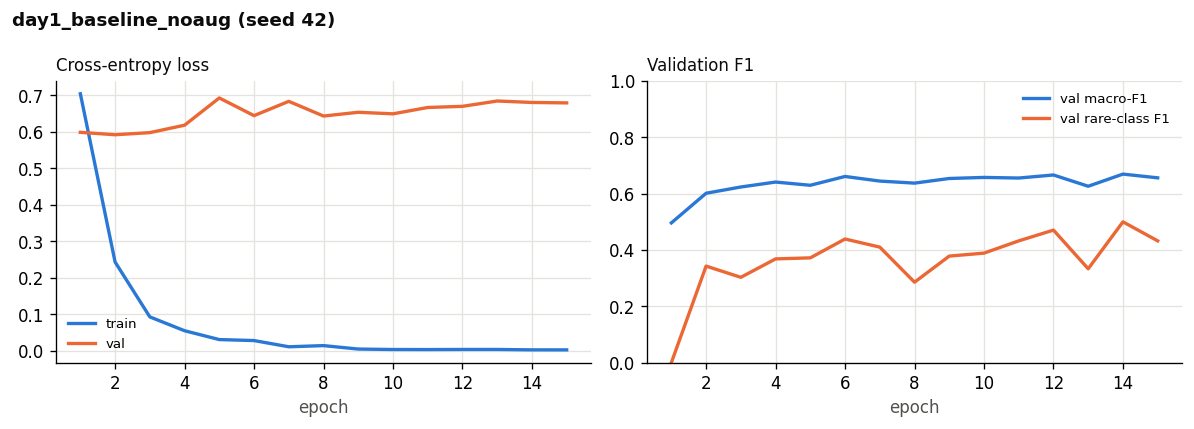

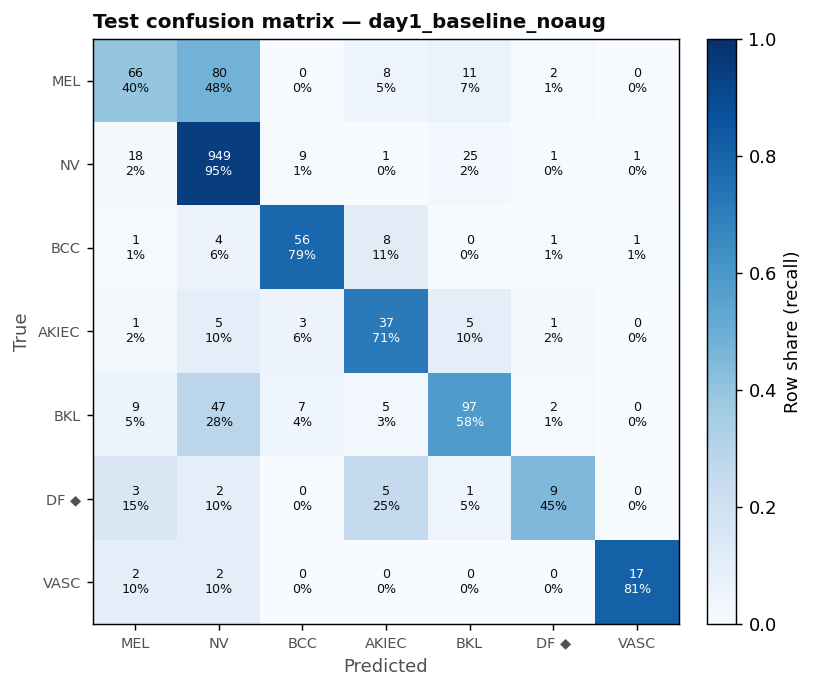


Saved run artefacts to /content/drive/MyDrive/rare-disease-aug/results/runs/day1_baseline_noaug_seed42
Appended results row to /content/drive/MyDrive/rare-disease-aug/results/results_log.csv


In [13]:
cfg = TrainConfig(
    run_name='day1_baseline_noaug', config_name='baseline_no_aug',
    arch='resnet18', pretrained=True, epochs=15, batch_size=64, lr=1e-4, weight_decay=1e-4,
    seed=42, split_seed=42, rare_class=RARE,
    notes='Day 1 control: real data only, no augmentation, plain cross-entropy',
)
out = run_experiment(cfg, paths, images, split)

## 6 · Honest evaluation on the held-out test set

The test set is used **once**, with the checkpoint picked on validation.

In [14]:
t = out['summary']['test']
test_labels = split.loc[split.split == 'test', 'label']
always_nv = (test_labels == 'NV').mean()

headline = pd.DataFrame({
    'metric': ['Overall accuracy', 'Balanced accuracy', 'Macro-F1',
               f'{RARE} precision', f'{RARE} recall', f'{RARE} F1', f'{RARE} AUROC (one-vs-rest)'],
    'value': [t['accuracy'], t['balanced_accuracy'], t['macro_f1'],
              t['rare_precision'], t['rare_recall'], t['rare_f1'], t['rare_auroc']],
}).set_index('metric').round(3)
display(headline)
print(f"{RARE} test support: {t['rare_support']} images | predicted as {RARE}: {t['rare_n_predicted']} images")
print(f"Reference: always predicting NV would score {always_nv:.1%} accuracy but 0.0 {RARE} recall "
      f"— that's why accuracy is not the headline metric.")

,value
metric,
Overall accuracy,0.820
Balanced accuracy,0.669
Macro-F1,0.684
DF precision,0.562
DF recall,0.450
DF F1,0.500
DF AUROC (one-vs-rest),0.951


DF test support: 20 images | predicted as DF: 16 images
Reference: always predicting NV would score 66.8% accuracy but 0.0 DF recall — that's why accuracy is not the headline metric.


In [15]:
display(out['report'])   # per-class precision / recall / F1 on test

,precision,recall,f1-score,support
MEL,0.6600,0.3952,0.4944,167.0000
NV,0.8714,0.9452,0.9068,1004.0000
BCC,0.7467,0.7887,0.7671,71.0000
AKIEC,0.5781,0.7115,0.6379,52.0000
BKL,0.6978,0.5808,0.6340,167.0000
DF,0.5625,0.4500,0.5000,20.0000
VASC,0.8947,0.8095,0.8500,21.0000
accuracy,0.8196,0.8196,0.8196,0.8196
macro avg,0.7159,0.6687,0.6843,1502.0000
weighted avg,0.8088,0.8196,0.8085,1502.0000


In [16]:
# Where do the missed rare-class images go?
preds = pd.read_csv(out['run_dir'] / 'test_predictions.csv')
rare_rows = preds[preds.label == RARE]
print(f'True {RARE} test images were predicted as:')
display(rare_rows.pred.value_counts().rename('count').to_frame())

True DF test images were predicted as:


,count
pred,
DF,9
AKIEC,5
MEL,3
NV,2
BKL,1


## 7 · Results log — the "before" state

One row per run. Days 2 and 4 append to this same file, so the final comparison table is just this CSV.
Per-run artefacts (config, curves, confusion matrix, per-image predictions, weights) are in `results/runs/`.

In [17]:
log = pd.read_csv(paths.results_log)
display(log[['timestamp', 'config', 'seed', 'rare_class', 'best_epoch', 'test_accuracy', 'test_macro_f1',
             'rare_precision', 'rare_recall', 'rare_f1', 'rare_auroc', 'rare_support']])

,timestamp,config,seed,rare_class,best_epoch,test_accuracy,test_macro_f1,rare_precision,rare_recall,rare_f1,rare_auroc,rare_support
0,2026-09-24T11:14:12,baseline_no_aug,42,DF,14,0.8196,0.6843,0.5625,0.45,0.5,0.9507,20


## ✅ Day 1 checklist — send these back before Day 2

1. The class-distribution table (section 2) and which rare class was chosen
2. The split summary table (section 3) — the leak count must be **0**
3. The headline metrics table (section 6) and the confusion matrix
4. The `results_log.csv` row (section 7)

**What "looks right" means** (rough ranges for this setup, not targets):

* Overall accuracy roughly 0.80–0.90, macro-F1 roughly 0.55–0.75
* Rare-class recall clearly below the NV / BCC recall — that's the expected weakness and the whole point of the control
* With only ~15–20 rare test images, one image changes recall by ~5–7 points, so the rare-class numbers are noisy (Days 6–7 fix this with multiple seeds)

**Red flags:** accuracy > 0.95 (suspect leakage) · validation loss rising from epoch 1 · the model predicting only NV (accuracy ≈ 0.67)